In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("../data/processed/sales_feature_engineered.xlsx")

df.head()

,Order Date,Sales,Year,Quarter,Month,Week,Day,DayOfWeek,IsWeekend,Lag_1,Lag_7,Lag_30,Rolling_Mean_7,Rolling_Mean_30,Rolling_STD_7,Expanding_Mean,Month_Sin,Month_Cos,Day_Sin,Day_Cos
0,2011-02-06,0.00,2011,1,2,5,6,6,1,134.384,0.000,19.44,76.358857,105.437633,109.021650,102.663516,0.866025,0.5,-0.781831,0.623490
1,2011-02-07,0.00,2011,1,2,6,7,0,0,0.000,0.000,0.00,76.358857,105.437633,109.021650,99.455281,0.866025,0.5,0.000000,1.000000
2,2011-02-08,0.00,2011,1,2,6,8,1,0,0.000,290.666,0.00,34.835143,105.437633,56.491758,96.441485,0.866025,0.5,0.781831,0.623490
3,2011-02-09,14.56,2011,1,2,6,9,2,0,0.000,0.000,0.00,36.915143,105.922967,55.249769,94.033206,0.866025,0.5,0.974928,-0.222521
4,2011-02-10,0.00,2011,1,2,6,10,3,0,14.560,12.350,0.00,35.150857,105.922967,56.351152,91.346543,0.866025,0.5,0.433884,-0.900969


In [3]:
lr_model = joblib.load("../models/linear_regression.pkl")

In [4]:
print(df["Order Date"].max())

2014-12-31 00:00:00


In [5]:
future_days = 30

last_date = df["Order Date"].max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=future_days,
    freq="D"
)

future_df = pd.DataFrame({
    "Order Date": future_dates
})

future_df.head()

,Order Date
0,2015-01-01
1,2015-01-02
2,2015-01-03
3,2015-01-04
4,2015-01-05


In [6]:
for col in df.columns:
    print(col)

Order Date
Sales
Year
Quarter
Month
Week
Day
DayOfWeek
IsWeekend
Lag_1
Lag_7
Lag_30
Rolling_Mean_7
Rolling_Mean_30
Rolling_STD_7
Expanding_Mean
Month_Sin
Month_Cos
Day_Sin
Day_Cos


In [7]:
historical_sales = df["Sales"].tolist()

forecast_results = []

In [8]:
for future_date in future_dates:

    # Date Features
    year = future_date.year
    quarter = future_date.quarter
    month = future_date.month
    week = future_date.isocalendar().week
    day = future_date.day
    dayofweek = future_date.dayofweek
    isweekend = 1 if dayofweek >= 5 else 0

    # Lag Features
    lag_1 = historical_sales[-1]
    lag_7 = historical_sales[-7]
    lag_30 = historical_sales[-30]

    # Rolling Features
    rolling_mean_7 = np.mean(historical_sales[-7:])
    rolling_mean_30 = np.mean(historical_sales[-30:])
    rolling_std_7 = np.std(historical_sales[-7:])
    expanding_mean = np.mean(historical_sales)

    # Cyclic Features
    month_sin = np.sin(2 * np.pi * month / 12)
    month_cos = np.cos(2 * np.pi * month / 12)

    day_sin = np.sin(2 * np.pi * day / 31)
    day_cos = np.cos(2 * np.pi * day / 31)

    # Create feature row
    X_future = pd.DataFrame([{
        "Year": year,
        "Quarter": quarter,
        "Month": month,
        "Week": week,
        "Day": day,
        "DayOfWeek": dayofweek,
        "IsWeekend": isweekend,
        "Lag_1": lag_1,
        "Lag_7": lag_7,
        "Lag_30": lag_30,
        "Rolling_Mean_7": rolling_mean_7,
        "Rolling_Mean_30": rolling_mean_30,
        "Rolling_STD_7": rolling_std_7,
        "Expanding_Mean": expanding_mean,
        "Month_Sin": month_sin,
        "Month_Cos": month_cos,
        "Day_Sin": day_sin,
        "Day_Cos": day_cos
    }])

    # Predict next day's sales
    prediction = lr_model.predict(X_future)[0]

    # Store prediction
    forecast_results.append({
        "Order Date": future_date,
        "Forecasted Sales": prediction
    })

    # Add prediction for next iteration
    historical_sales.append(prediction)

In [9]:
forecast_df = pd.DataFrame(forecast_results)

forecast_df.head()

,Order Date,Forecasted Sales
0,2015-01-01,977.804114
1,2015-01-02,-77.192045
2,2015-01-03,-78.160576
3,2015-01-04,-162.989518
4,2015-01-05,574.153204


In [10]:
forecast_df.to_excel(
    "../data/processed/future_sales_forecast.xlsx",
    index=False
)

print("✅ future_sales_forecast.xlsx saved successfully!")

✅ future_sales_forecast.xlsx saved successfully!


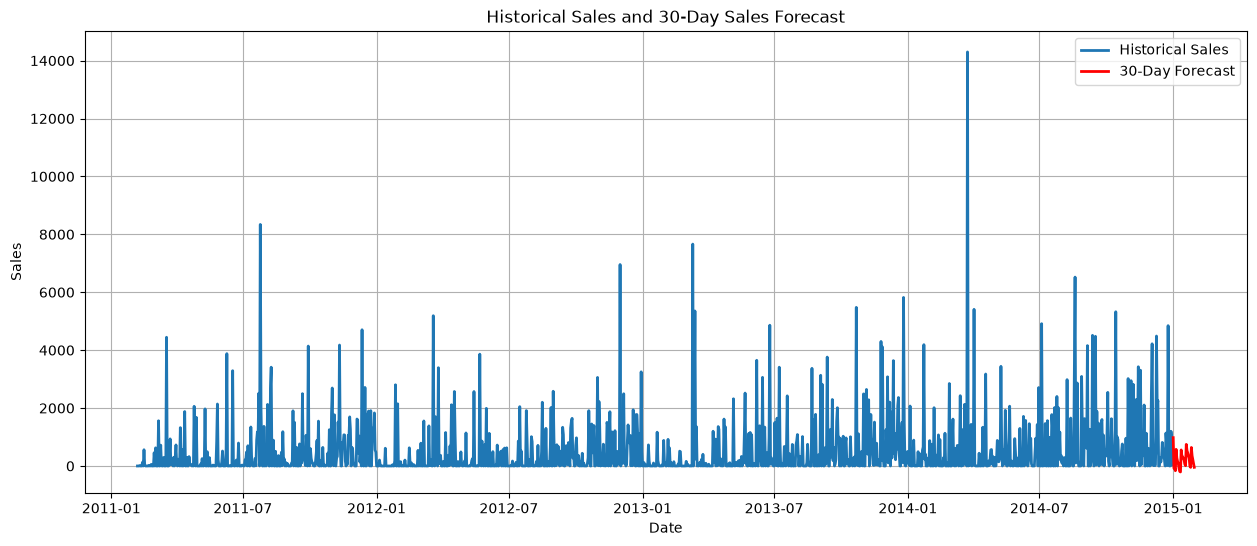

In [11]:
plt.figure(figsize=(15,6))

# Historical Sales
plt.plot(
    df["Order Date"],
    df["Sales"],
    label="Historical Sales",
    linewidth=2
)

# Forecast
plt.plot(
    forecast_df["Order Date"],
    forecast_df["Forecasted Sales"],
    label="30-Day Forecast",
    linewidth=2,
    color="red"
)

plt.title("Historical Sales and 30-Day Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.grid(True)

plt.show()

# Business Insights

## Future Sales Forecast

- The Linear Regression model was used to forecast the next 30 days of sales.
- Lag features and rolling statistics were updated recursively for each future prediction.
- The forecast can support inventory planning, demand forecasting, and business decision-making.
- This forecasting pipeline can be rerun whenever new sales data becomes available.